In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()


In [3]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")
conn.commit()


In [4]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())


[('sales',), ('sqlite_sequence',)]


In [5]:
cursor.executemany("""
INSERT INTO sales (product, quantity, price)
VALUES (?, ?, ?)
""", [
    ("Shampoo", 10, 150),
    ("Soap", 25, 40),
    ("Toothpaste", 15, 60),
    ("Cream", 8, 200),
    ("Lotion", 12, 180)
])
conn.commit()


In [6]:
cursor.execute("SELECT * FROM sales;")
print(cursor.fetchall())


[(1, 'Shampoo', 10, 150.0), (2, 'Soap', 25, 40.0), (3, 'Toothpaste', 15, 60.0), (4, 'Cream', 8, 200.0), (5, 'Lotion', 12, 180.0)]


In [7]:
query = """
SELECT product,
       SUM(quantity) AS total_quantity,
       SUM(quantity * price) AS total_revenue
FROM sales
GROUP BY product;
"""

df = pd.read_sql_query(query, conn)
print(df)


      product  total_quantity  total_revenue
0       Cream               8         1600.0
1      Lotion              12         2160.0
2     Shampoo              10         1500.0
3        Soap              25         1000.0
4  Toothpaste              15          900.0


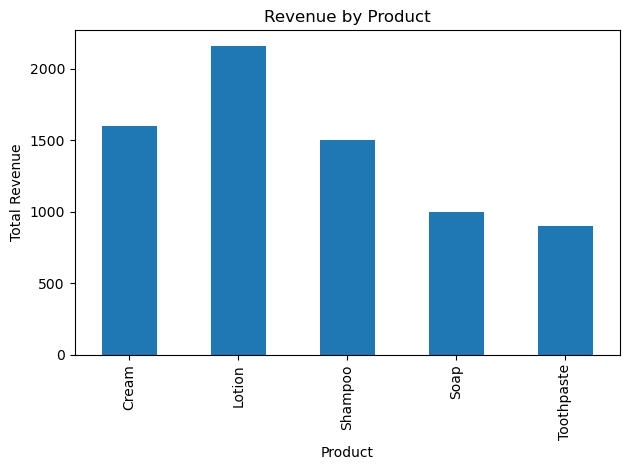

In [8]:
df.plot(kind='bar', x='product', y='total_revenue', legend=False)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


In [9]:
df_summary = pd.read_sql_query(query, conn)
print(df_summary)


      product  total_quantity  total_revenue
0       Cream               8         1600.0
1      Lotion              12         2160.0
2     Shampoo              10         1500.0
3        Soap              25         1000.0
4  Toothpaste              15          900.0


In [10]:
plt.savefig("sales_chart.png")


<Figure size 640x480 with 0 Axes>

In [11]:
conn.close()
